# Binance Spot and USD-M Validation

This notebook validates that `quantleet` can fetch Binance spot and USD-M OHLCV data and plot simple charts.

In [1]:
from __future__ import annotations

from datetime import UTC, datetime

import matplotlib.pyplot as plt

from quantleet.integrations.venues.ccxt import Exchange, MarketType

fatal: bad revision 'HEAD'


In [2]:
spot_exchange = Exchange(name="binance", market_type=MarketType.SPOT)
usdm_exchange = Exchange(name="binance", market_type=MarketType.USDM)

spot_rows = spot_exchange.fetch_ohlcv(
    symbol="BTC/USDT",
    timeframe="1h",
    limit=200,
)

usdm_rows = usdm_exchange.fetch_ohlcv(
    symbol="BTC/USDT:USDT",
    timeframe="1h",
    limit=200,
)

In [3]:
assert spot_rows, "spot fetch returned no rows"
assert usdm_rows, "usdm fetch returned no rows"


def is_strictly_ascending(rows: list) -> bool:
    pairs = zip(rows, rows[1:], strict=False)
    return all(left.timestamp < right.timestamp for left, right in pairs)


assert is_strictly_ascending(spot_rows)
assert is_strictly_ascending(usdm_rows)

In [4]:
def summarize(label: str, rows: list) -> None:
    print(
        label,
        {
            "rows": len(rows),
            "start": datetime.fromtimestamp(rows[0].timestamp / 1000, UTC).isoformat(),
            "end": datetime.fromtimestamp(rows[-1].timestamp / 1000, UTC).isoformat(),
        },
    )


summarize("spot", spot_rows)
summarize("usdm", usdm_rows)

spot {'rows': 200, 'start': '2026-03-07T02:00:00+00:00', 'end': '2026-03-15T09:00:00+00:00'}
usdm {'rows': 200, 'start': '2026-03-07T02:00:00+00:00', 'end': '2026-03-15T09:00:00+00:00'}


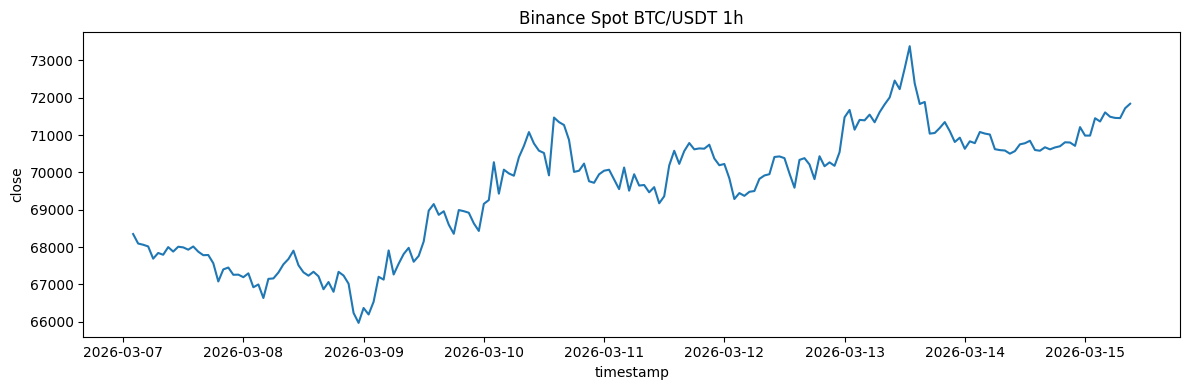

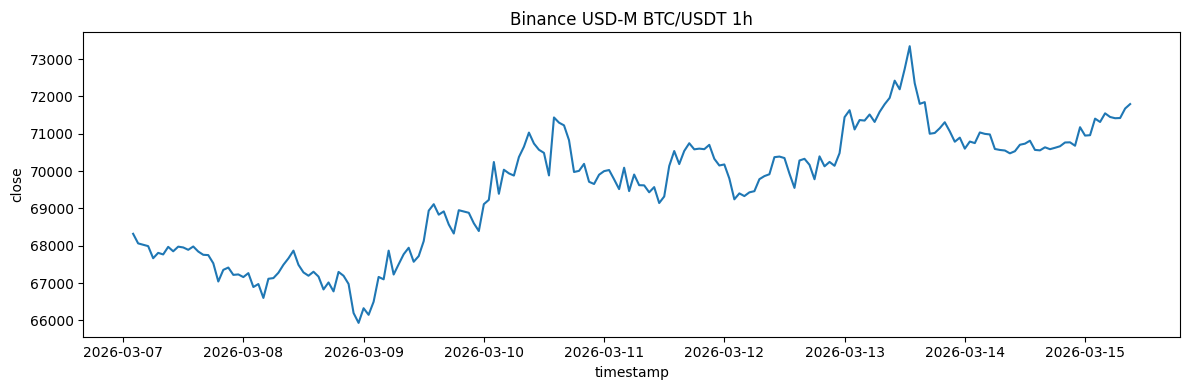

In [5]:
def plot_rows(title: str, rows: list) -> None:
    xs = [datetime.fromtimestamp(row.timestamp / 1000, UTC) for row in rows]
    ys = [row.close for row in rows]
    plt.figure(figsize=(12, 4))
    plt.plot(xs, ys)
    plt.title(title)
    plt.xlabel("timestamp")
    plt.ylabel("close")
    plt.tight_layout()
    plt.show()


plot_rows("Binance Spot BTC/USDT 1h", spot_rows)
plot_rows("Binance USD-M BTC/USDT 1h", usdm_rows)